# Assignment 08: Sentiment Analysis on Vehicle Feedback Using PyTorch LSTM

## Objective
Build and train a Recurrent Neural Network (RNN) using **PyTorch LSTM** to perform sentiment classification (**Negative**, **Neutral**, **Positive**) on automotive customer feedback and technical vehicle telemetry/specifications.

## Key Requirements & Scope
- **Dataset:** ~450 unique sentences (~150 Positive, ~150 Negative, ~150 Neutral specifications).
- **Leakage Prevention:** 0 overlapping sentences between train and test splits (`train_test_split` with `stratify=y`, `random_state=42`).
- **Padding Strategy:** **Left-Padding** (`[0, 0, ..., w1, w2]`) ensures the PyTorch LSTM hidden state `hn[-1]` / `lstm_out[:, -1, :]` processes the actual final word vector instead of zero padding tokens.
- **Model:** PyTorch `nn.Embedding` -> `nn.LSTM` -> `nn.Dropout` -> `nn.Linear(hidden_dim, 3)`.
- **Evaluation:** Test Accuracy, Classification Report (Precision, Recall, F1-score for all 3 classes), Confusion Matrix, and 6 sample inference predictions.


In [1]:
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Set seed for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cpu


In [2]:
# Synthetic Automotive Feedback & Technical Specifications Dataset
pos_texts = ['The engine performance is outstanding and accelerates smoothly.', 'The engine performance is impressive and accelerates smoothly.', 'The engine performance is excellent and accelerates smoothly.', 'The engine performance is superb and accelerates smoothly.', 'The engine performance is top-notch and accelerates smoothly.', 'The engine performance is wonderful and accelerates smoothly.', 'The engine performance is fantastic and accelerates smoothly.', 'The engine performance is remarkable and accelerates smoothly.', 'The engine performance is exceptional and accelerates smoothly.', 'The engine performance is brilliant and accelerates smoothly.', 'Brake response is outstanding and provides great stopping confidence.', 'Brake response is impressive and provides great stopping confidence.', 'Brake response is excellent and provides great stopping confidence.', 'Brake response is superb and provides great stopping confidence.', 'Brake response is top-notch and provides great stopping confidence.', 'Brake response is wonderful and provides great stopping confidence.', 'Brake response is fantastic and provides great stopping confidence.', 'Brake response is remarkable and provides great stopping confidence.', 'Brake response is exceptional and provides great stopping confidence.', 'Brake response is brilliant and provides great stopping confidence.', 'Fuel efficiency is outstanding for daily commuting and highway driving.', 'Fuel efficiency is impressive for daily commuting and highway driving.', 'Fuel efficiency is excellent for daily commuting and highway driving.', 'Fuel efficiency is superb for daily commuting and highway driving.', 'Fuel efficiency is top-notch for daily commuting and highway driving.', 'Fuel efficiency is wonderful for daily commuting and highway driving.', 'Fuel efficiency is fantastic for daily commuting and highway driving.', 'Fuel efficiency is remarkable for daily commuting and highway driving.', 'Fuel efficiency is exceptional for daily commuting and highway driving.', 'Fuel efficiency is brilliant for daily commuting and highway driving.', 'The cabin insulation is outstanding even at very high speeds.', 'The cabin insulation is impressive even at very high speeds.', 'The cabin insulation is excellent even at very high speeds.', 'The cabin insulation is superb even at very high speeds.', 'The cabin insulation is top-notch even at very high speeds.', 'The cabin insulation is wonderful even at very high speeds.', 'The cabin insulation is fantastic even at very high speeds.', 'The cabin insulation is remarkable even at very high speeds.', 'The cabin insulation is exceptional even at very high speeds.', 'The cabin insulation is brilliant even at very high speeds.', 'Steering precision is outstanding and delivers great feedback.', 'Steering precision is impressive and delivers great feedback.', 'Steering precision is excellent and delivers great feedback.', 'Steering precision is superb and delivers great feedback.', 'Steering precision is top-notch and delivers great feedback.', 'Steering precision is wonderful and delivers great feedback.', 'Steering precision is fantastic and delivers great feedback.', 'Steering precision is remarkable and delivers great feedback.', 'Steering precision is exceptional and delivers great feedback.', 'Steering precision is brilliant and delivers great feedback.', 'Suspension handles engine smoothly and absorbs bumps effortlessly.', 'Suspension handles powertrain smoothly and absorbs bumps effortlessly.', 'Suspension handles motor smoothly and absorbs bumps effortlessly.', 'Suspension handles turbocharger smoothly and absorbs bumps effortlessly.', 'Suspension handles hybrid system smoothly and absorbs bumps effortlessly.', 'Suspension handles drivetrain smoothly and absorbs bumps effortlessly.', 'Suspension handles clutch smoothly and absorbs bumps effortlessly.', 'Suspension handles throttle smoothly and absorbs bumps effortlessly.', 'Suspension handles exhaust system smoothly and absorbs bumps effortlessly.', 'Suspension handles vehicle suspension smoothly and absorbs bumps effortlessly.', 'Infotainment screen is outstanding, responsive, and intuitive to use.', 'Infotainment screen is impressive, responsive, and intuitive to use.', 'Infotainment screen is excellent, responsive, and intuitive to use.', 'Infotainment screen is superb, responsive, and intuitive to use.', 'Infotainment screen is top-notch, responsive, and intuitive to use.', 'Infotainment screen is wonderful, responsive, and intuitive to use.', 'Infotainment screen is fantastic, responsive, and intuitive to use.', 'Infotainment screen is remarkable, responsive, and intuitive to use.', 'Infotainment screen is exceptional, responsive, and intuitive to use.', 'Infotainment screen is brilliant, responsive, and intuitive to use.', 'Seats are outstanding and provide great lumbar support for long trips.', 'Seats are impressive and provide great lumbar support for long trips.', 'Seats are excellent and provide great lumbar support for long trips.', 'Seats are superb and provide great lumbar support for long trips.', 'Seats are top-notch and provide great lumbar support for long trips.', 'Seats are wonderful and provide great lumbar support for long trips.', 'Seats are fantastic and provide great lumbar support for long trips.', 'Seats are remarkable and provide great lumbar support for long trips.', 'Seats are exceptional and provide great lumbar support for long trips.', 'Seats are brilliant and provide great lumbar support for long trips.', 'Air conditioning system is outstanding and cools the vehicle quickly.', 'Air conditioning system is impressive and cools the vehicle quickly.', 'Air conditioning system is excellent and cools the vehicle quickly.', 'Air conditioning system is superb and cools the vehicle quickly.', 'Air conditioning system is top-notch and cools the vehicle quickly.', 'Air conditioning system is wonderful and cools the vehicle quickly.', 'Air conditioning system is fantastic and cools the vehicle quickly.', 'Air conditioning system is remarkable and cools the vehicle quickly.', 'Air conditioning system is exceptional and cools the vehicle quickly.', 'Air conditioning system is brilliant and cools the vehicle quickly.', 'Transmission shifting is outstanding and seamless across all gears.', 'Transmission shifting is impressive and seamless across all gears.', 'Transmission shifting is excellent and seamless across all gears.', 'Transmission shifting is superb and seamless across all gears.', 'Transmission shifting is top-notch and seamless across all gears.', 'Transmission shifting is wonderful and seamless across all gears.', 'Transmission shifting is fantastic and seamless across all gears.', 'Transmission shifting is remarkable and seamless across all gears.', 'Transmission shifting is exceptional and seamless across all gears.', 'Transmission shifting is brilliant and seamless across all gears.', 'Engine power delivery is outstanding with strong torque response.', 'Engine power delivery is impressive with strong torque response.', 'Engine power delivery is excellent with strong torque response.', 'Engine power delivery is superb with strong torque response.', 'Engine power delivery is top-notch with strong torque response.', 'Engine power delivery is wonderful with strong torque response.', 'Engine power delivery is fantastic with strong torque response.', 'Engine power delivery is remarkable with strong torque response.', 'Engine power delivery is exceptional with strong torque response.', 'Engine power delivery is brilliant with strong torque response.', 'Headlight illumination is outstanding for night driving visibility.', 'Headlight illumination is impressive for night driving visibility.', 'Headlight illumination is excellent for night driving visibility.', 'Headlight illumination is superb for night driving visibility.', 'Headlight illumination is top-notch for night driving visibility.', 'Headlight illumination is wonderful for night driving visibility.', 'Headlight illumination is fantastic for night driving visibility.', 'Headlight illumination is remarkable for night driving visibility.', 'Headlight illumination is exceptional for night driving visibility.', 'Headlight illumination is brilliant for night driving visibility.', 'Build quality of the chassis feels outstanding and solid.', 'Build quality of the chassis feels impressive and solid.', 'Build quality of the chassis feels excellent and solid.', 'Build quality of the chassis feels superb and solid.', 'Build quality of the chassis feels top-notch and solid.', 'Build quality of the chassis feels wonderful and solid.', 'Build quality of the chassis feels fantastic and solid.', 'Build quality of the chassis feels remarkable and solid.', 'Build quality of the chassis feels exceptional and solid.', 'Build quality of the chassis feels brilliant and solid.', 'Sound system audio quality is outstanding with deep bass clarity.', 'Sound system audio quality is impressive with deep bass clarity.', 'Sound system audio quality is excellent with deep bass clarity.', 'Sound system audio quality is superb with deep bass clarity.', 'Sound system audio quality is top-notch with deep bass clarity.', 'Sound system audio quality is wonderful with deep bass clarity.', 'Sound system audio quality is fantastic with deep bass clarity.', 'Sound system audio quality is remarkable with deep bass clarity.', 'Sound system audio quality is exceptional with deep bass clarity.', 'Sound system audio quality is brilliant with deep bass clarity.', 'Safety features like lane assist function outstanding and reliably.', 'Safety features like lane assist function impressive and reliably.', 'Safety features like lane assist function excellent and reliably.', 'Safety features like lane assist function superb and reliably.', 'Safety features like lane assist function top-notch and reliably.', 'Safety features like lane assist function wonderful and reliably.', 'Safety features like lane assist function fantastic and reliably.', 'Safety features like lane assist function remarkable and reliably.', 'Safety features like lane assist function exceptional and reliably.', 'Safety features like lane assist function brilliant and reliably.']
neg_texts = ['The engine performance is terrible and overheats quickly.', 'The engine performance is disappointing and overheats quickly.', 'The engine performance is subpar and overheats quickly.', 'The engine performance is awful and overheats quickly.', 'The engine performance is dreadful and overheats quickly.', 'The engine performance is frustrating and overheats quickly.', 'The engine performance is poor and overheats quickly.', 'The engine performance is horrible and overheats quickly.', 'The engine performance is unacceptable and overheats quickly.', 'The engine performance is defective and overheats quickly.', 'Brake pedal feels terrible and lacks sufficient stopping power.', 'Brake pedal feels disappointing and lacks sufficient stopping power.', 'Brake pedal feels subpar and lacks sufficient stopping power.', 'Brake pedal feels awful and lacks sufficient stopping power.', 'Brake pedal feels dreadful and lacks sufficient stopping power.', 'Brake pedal feels frustrating and lacks sufficient stopping power.', 'Brake pedal feels poor and lacks sufficient stopping power.', 'Brake pedal feels horrible and lacks sufficient stopping power.', 'Brake pedal feels unacceptable and lacks sufficient stopping power.', 'Brake pedal feels defective and lacks sufficient stopping power.', 'Fuel economy is terrible and significantly worse than claimed.', 'Fuel economy is disappointing and significantly worse than claimed.', 'Fuel economy is subpar and significantly worse than claimed.', 'Fuel economy is awful and significantly worse than claimed.', 'Fuel economy is dreadful and significantly worse than claimed.', 'Fuel economy is frustrating and significantly worse than claimed.', 'Fuel economy is poor and significantly worse than claimed.', 'Fuel economy is horrible and significantly worse than claimed.', 'Fuel economy is unacceptable and significantly worse than claimed.', 'Fuel economy is defective and significantly worse than claimed.', 'Cabin noise level is terrible and intrusive during travel.', 'Cabin noise level is disappointing and intrusive during travel.', 'Cabin noise level is subpar and intrusive during travel.', 'Cabin noise level is awful and intrusive during travel.', 'Cabin noise level is dreadful and intrusive during travel.', 'Cabin noise level is frustrating and intrusive during travel.', 'Cabin noise level is poor and intrusive during travel.', 'Cabin noise level is horrible and intrusive during travel.', 'Cabin noise level is unacceptable and intrusive during travel.', 'Cabin noise level is defective and intrusive during travel.', 'Steering response is terrible and feels completely disconnected.', 'Steering response is disappointing and feels completely disconnected.', 'Steering response is subpar and feels completely disconnected.', 'Steering response is awful and feels completely disconnected.', 'Steering response is dreadful and feels completely disconnected.', 'Steering response is frustrating and feels completely disconnected.', 'Steering response is poor and feels completely disconnected.', 'Steering response is horrible and feels completely disconnected.', 'Steering response is unacceptable and feels completely disconnected.', 'Steering response is defective and feels completely disconnected.', 'Suspension ride is terrible and transmits every road impact.', 'Suspension ride is disappointing and transmits every road impact.', 'Suspension ride is subpar and transmits every road impact.', 'Suspension ride is awful and transmits every road impact.', 'Suspension ride is dreadful and transmits every road impact.', 'Suspension ride is frustrating and transmits every road impact.', 'Suspension ride is poor and transmits every road impact.', 'Suspension ride is horrible and transmits every road impact.', 'Suspension ride is unacceptable and transmits every road impact.', 'Suspension ride is defective and transmits every road impact.', 'Infotainment system is terrible, crashes often, and lags.', 'Infotainment system is disappointing, crashes often, and lags.', 'Infotainment system is subpar, crashes often, and lags.', 'Infotainment system is awful, crashes often, and lags.', 'Infotainment system is dreadful, crashes often, and lags.', 'Infotainment system is frustrating, crashes often, and lags.', 'Infotainment system is poor, crashes often, and lags.', 'Infotainment system is horrible, crashes often, and lags.', 'Infotainment system is unacceptable, crashes often, and lags.', 'Infotainment system is defective, crashes often, and lags.', 'Seats are terrible and cause severe back discomfort on long drives.', 'Seats are disappointing and cause severe back discomfort on long drives.', 'Seats are subpar and cause severe back discomfort on long drives.', 'Seats are awful and cause severe back discomfort on long drives.', 'Seats are dreadful and cause severe back discomfort on long drives.', 'Seats are frustrating and cause severe back discomfort on long drives.', 'Seats are poor and cause severe back discomfort on long drives.', 'Seats are horrible and cause severe back discomfort on long drives.', 'Seats are unacceptable and cause severe back discomfort on long drives.', 'Seats are defective and cause severe back discomfort on long drives.', 'Air conditioner output is terrible and fails to cool the cabin.', 'Air conditioner output is disappointing and fails to cool the cabin.', 'Air conditioner output is subpar and fails to cool the cabin.', 'Air conditioner output is awful and fails to cool the cabin.', 'Air conditioner output is dreadful and fails to cool the cabin.', 'Air conditioner output is frustrating and fails to cool the cabin.', 'Air conditioner output is poor and fails to cool the cabin.', 'Air conditioner output is horrible and fails to cool the cabin.', 'Air conditioner output is unacceptable and fails to cool the cabin.', 'Air conditioner output is defective and fails to cool the cabin.', 'Transmission behavior is terrible with frequent clanking noises.', 'Transmission behavior is disappointing with frequent clanking noises.', 'Transmission behavior is subpar with frequent clanking noises.', 'Transmission behavior is awful with frequent clanking noises.', 'Transmission behavior is dreadful with frequent clanking noises.', 'Transmission behavior is frustrating with frequent clanking noises.', 'Transmission behavior is poor with frequent clanking noises.', 'Transmission behavior is horrible with frequent clanking noises.', 'Transmission behavior is unacceptable with frequent clanking noises.', 'Transmission behavior is defective with frequent clanking noises.', 'Engine power is terrible and struggles under moderate acceleration.', 'Engine power is disappointing and struggles under moderate acceleration.', 'Engine power is subpar and struggles under moderate acceleration.', 'Engine power is awful and struggles under moderate acceleration.', 'Engine power is dreadful and struggles under moderate acceleration.', 'Engine power is frustrating and struggles under moderate acceleration.', 'Engine power is poor and struggles under moderate acceleration.', 'Engine power is horrible and struggles under moderate acceleration.', 'Engine power is unacceptable and struggles under moderate acceleration.', 'Engine power is defective and struggles under moderate acceleration.', 'Headlights are terrible and provide poor night road visibility.', 'Headlights are disappointing and provide poor night road visibility.', 'Headlights are subpar and provide poor night road visibility.', 'Headlights are awful and provide poor night road visibility.', 'Headlights are dreadful and provide poor night road visibility.', 'Headlights are frustrating and provide poor night road visibility.', 'Headlights are poor and provide poor night road visibility.', 'Headlights are horrible and provide poor night road visibility.', 'Headlights are unacceptable and provide poor night road visibility.', 'Headlights are defective and provide poor night road visibility.', 'Interior trim quality is terrible with loose plastic parts.', 'Interior trim quality is disappointing with loose plastic parts.', 'Interior trim quality is subpar with loose plastic parts.', 'Interior trim quality is awful with loose plastic parts.', 'Interior trim quality is dreadful with loose plastic parts.', 'Interior trim quality is frustrating with loose plastic parts.', 'Interior trim quality is poor with loose plastic parts.', 'Interior trim quality is horrible with loose plastic parts.', 'Interior trim quality is unacceptable with loose plastic parts.', 'Interior trim quality is defective with loose plastic parts.', 'Audio system sound is terrible and heavily distorted at volume.', 'Audio system sound is disappointing and heavily distorted at volume.', 'Audio system sound is subpar and heavily distorted at volume.', 'Audio system sound is awful and heavily distorted at volume.', 'Audio system sound is dreadful and heavily distorted at volume.', 'Audio system sound is frustrating and heavily distorted at volume.', 'Audio system sound is poor and heavily distorted at volume.', 'Audio system sound is horrible and heavily distorted at volume.', 'Audio system sound is unacceptable and heavily distorted at volume.', 'Audio system sound is defective and heavily distorted at volume.', 'Driver assistance tech is terrible and triggers false alerts.', 'Driver assistance tech is disappointing and triggers false alerts.', 'Driver assistance tech is subpar and triggers false alerts.', 'Driver assistance tech is awful and triggers false alerts.', 'Driver assistance tech is dreadful and triggers false alerts.', 'Driver assistance tech is frustrating and triggers false alerts.', 'Driver assistance tech is poor and triggers false alerts.', 'Driver assistance tech is horrible and triggers false alerts.', 'Driver assistance tech is unacceptable and triggers false alerts.', 'Driver assistance tech is defective and triggers false alerts.']
neu_texts = ['The engine displacement is measured at 1.2 liters.', 'The engine displacement is measured at 1.2 liters. under standard conditions.', 'The engine displacement is measured at 1.2 liters. as per OEM manual.', 'The engine displacement is measured at 1.2 liters. for base configuration.', 'The engine displacement is measured at 1.2 liters. specified by manufacturer.', 'The engine displacement is measured at 1.2 liters. according to technical datasheet.', 'The engine displacement is measured at 1.2 liters. in standard trim.', 'The engine displacement is measured at 1.2 liters. for standard variant.', 'The engine displacement is measured at 1.2 liters. during factory testing.', 'The engine displacement is measured at 1.2 liters. listed in specifications.', 'Fuel tank total capacity is rated at 40 liters.', 'Fuel tank total capacity is rated at 40 liters. under standard conditions.', 'Fuel tank total capacity is rated at 40 liters. as per OEM manual.', 'Fuel tank total capacity is rated at 40 liters. for base configuration.', 'Fuel tank total capacity is rated at 40 liters. specified by manufacturer.', 'Fuel tank total capacity is rated at 40 liters. according to technical datasheet.', 'Fuel tank total capacity is rated at 40 liters. in standard trim.', 'Fuel tank total capacity is rated at 40 liters. for standard variant.', 'Fuel tank total capacity is rated at 40 liters. during factory testing.', 'Fuel tank total capacity is rated at 40 liters. listed in specifications.', 'Wheel rim size installed is 15 inches.', 'Wheel rim size installed is 15 inches. under standard conditions.', 'Wheel rim size installed is 15 inches. as per OEM manual.', 'Wheel rim size installed is 15 inches. for base configuration.', 'Wheel rim size installed is 15 inches. specified by manufacturer.', 'Wheel rim size installed is 15 inches. according to technical datasheet.', 'Wheel rim size installed is 15 inches. in standard trim.', 'Wheel rim size installed is 15 inches. for standard variant.', 'Wheel rim size installed is 15 inches. during factory testing.', 'Wheel rim size installed is 15 inches. listed in specifications.', 'Recommended cold tire pressure setting is 1.2 psi.', 'Recommended cold tire pressure setting is 1.2 psi. under standard conditions.', 'Recommended cold tire pressure setting is 1.2 psi. as per OEM manual.', 'Recommended cold tire pressure setting is 1.2 psi. for base configuration.', 'Recommended cold tire pressure setting is 1.2 psi. specified by manufacturer.', 'Recommended cold tire pressure setting is 1.2 psi. according to technical datasheet.', 'Recommended cold tire pressure setting is 1.2 psi. in standard trim.', 'Recommended cold tire pressure setting is 1.2 psi. for standard variant.', 'Recommended cold tire pressure setting is 1.2 psi. during factory testing.', 'Recommended cold tire pressure setting is 1.2 psi. listed in specifications.', 'Engine oil volume required is 40 liters.', 'Engine oil volume required is 40 liters. under standard conditions.', 'Engine oil volume required is 40 liters. as per OEM manual.', 'Engine oil volume required is 40 liters. for base configuration.', 'Engine oil volume required is 40 liters. specified by manufacturer.', 'Engine oil volume required is 40 liters. according to technical datasheet.', 'Engine oil volume required is 40 liters. in standard trim.', 'Engine oil volume required is 40 liters. for standard variant.', 'Engine oil volume required is 40 liters. during factory testing.', 'Engine oil volume required is 40 liters. listed in specifications.', 'Vehicle total curb weight is specified as 15 kilograms.', 'Vehicle total curb weight is specified as 15 kilograms. under standard conditions.', 'Vehicle total curb weight is specified as 15 kilograms. as per OEM manual.', 'Vehicle total curb weight is specified as 15 kilograms. for base configuration.', 'Vehicle total curb weight is specified as 15 kilograms. specified by manufacturer.', 'Vehicle total curb weight is specified as 15 kilograms. according to technical datasheet.', 'Vehicle total curb weight is specified as 15 kilograms. in standard trim.', 'Vehicle total curb weight is specified as 15 kilograms. for standard variant.', 'Vehicle total curb weight is specified as 15 kilograms. during factory testing.', 'Vehicle total curb weight is specified as 15 kilograms. listed in specifications.', 'Overall length of the vehicle body is 1.2 millimeters.', 'Overall length of the vehicle body is 1.2 millimeters. under standard conditions.', 'Overall length of the vehicle body is 1.2 millimeters. as per OEM manual.', 'Overall length of the vehicle body is 1.2 millimeters. for base configuration.', 'Overall length of the vehicle body is 1.2 millimeters. specified by manufacturer.', 'Overall length of the vehicle body is 1.2 millimeters. according to technical datasheet.', 'Overall length of the vehicle body is 1.2 millimeters. in standard trim.', 'Overall length of the vehicle body is 1.2 millimeters. for standard variant.', 'Overall length of the vehicle body is 1.2 millimeters. during factory testing.', 'Overall length of the vehicle body is 1.2 millimeters. listed in specifications.', 'Wheelbase dimension for this model is 40 millimeters.', 'Wheelbase dimension for this model is 40 millimeters. under standard conditions.', 'Wheelbase dimension for this model is 40 millimeters. as per OEM manual.', 'Wheelbase dimension for this model is 40 millimeters. for base configuration.', 'Wheelbase dimension for this model is 40 millimeters. specified by manufacturer.', 'Wheelbase dimension for this model is 40 millimeters. according to technical datasheet.', 'Wheelbase dimension for this model is 40 millimeters. in standard trim.', 'Wheelbase dimension for this model is 40 millimeters. for standard variant.', 'Wheelbase dimension for this model is 40 millimeters. during factory testing.', 'Wheelbase dimension for this model is 40 millimeters. listed in specifications.', 'Rear trunk storage volume is rated at 15 liters.', 'Rear trunk storage volume is rated at 15 liters. under standard conditions.', 'Rear trunk storage volume is rated at 15 liters. as per OEM manual.', 'Rear trunk storage volume is rated at 15 liters. for base configuration.', 'Rear trunk storage volume is rated at 15 liters. specified by manufacturer.', 'Rear trunk storage volume is rated at 15 liters. according to technical datasheet.', 'Rear trunk storage volume is rated at 15 liters. in standard trim.', 'Rear trunk storage volume is rated at 15 liters. for standard variant.', 'Rear trunk storage volume is rated at 15 liters. during factory testing.', 'Rear trunk storage volume is rated at 15 liters. listed in specifications.', 'Electrical battery system operates at 1.2 volts.', 'Electrical battery system operates at 1.2 volts. under standard conditions.', 'Electrical battery system operates at 1.2 volts. as per OEM manual.', 'Electrical battery system operates at 1.2 volts. for base configuration.', 'Electrical battery system operates at 1.2 volts. specified by manufacturer.', 'Electrical battery system operates at 1.2 volts. according to technical datasheet.', 'Electrical battery system operates at 1.2 volts. in standard trim.', 'Electrical battery system operates at 1.2 volts. for standard variant.', 'Electrical battery system operates at 1.2 volts. during factory testing.', 'Electrical battery system operates at 1.2 volts. listed in specifications.', 'Ground clearance height is listed at 40 millimeters.', 'Ground clearance height is listed at 40 millimeters. under standard conditions.', 'Ground clearance height is listed at 40 millimeters. as per OEM manual.', 'Ground clearance height is listed at 40 millimeters. for base configuration.', 'Ground clearance height is listed at 40 millimeters. specified by manufacturer.', 'Ground clearance height is listed at 40 millimeters. according to technical datasheet.', 'Ground clearance height is listed at 40 millimeters. in standard trim.', 'Ground clearance height is listed at 40 millimeters. for standard variant.', 'Ground clearance height is listed at 40 millimeters. during factory testing.', 'Ground clearance height is listed at 40 millimeters. listed in specifications.', 'Service maintenance interval is scheduled every 15 kilometers.', 'Service maintenance interval is scheduled every 15 kilometers. under standard conditions.', 'Service maintenance interval is scheduled every 15 kilometers. as per OEM manual.', 'Service maintenance interval is scheduled every 15 kilometers. for base configuration.', 'Service maintenance interval is scheduled every 15 kilometers. specified by manufacturer.', 'Service maintenance interval is scheduled every 15 kilometers. according to technical datasheet.', 'Service maintenance interval is scheduled every 15 kilometers. in standard trim.', 'Service maintenance interval is scheduled every 15 kilometers. for standard variant.', 'Service maintenance interval is scheduled every 15 kilometers. during factory testing.', 'Service maintenance interval is scheduled every 15 kilometers. listed in specifications.', 'Turning radius requirement for U-turns is 1.2 meters.', 'Turning radius requirement for U-turns is 1.2 meters. under standard conditions.', 'Turning radius requirement for U-turns is 1.2 meters. as per OEM manual.', 'Turning radius requirement for U-turns is 1.2 meters. for base configuration.', 'Turning radius requirement for U-turns is 1.2 meters. specified by manufacturer.', 'Turning radius requirement for U-turns is 1.2 meters. according to technical datasheet.', 'Turning radius requirement for U-turns is 1.2 meters. in standard trim.', 'Turning radius requirement for U-turns is 1.2 meters. for standard variant.', 'Turning radius requirement for U-turns is 1.2 meters. during factory testing.', 'Turning radius requirement for U-turns is 1.2 meters. listed in specifications.', 'Coolant fluid total volume capacity is 40 liters.', 'Coolant fluid total volume capacity is 40 liters. under standard conditions.', 'Coolant fluid total volume capacity is 40 liters. as per OEM manual.', 'Coolant fluid total volume capacity is 40 liters. for base configuration.', 'Coolant fluid total volume capacity is 40 liters. specified by manufacturer.', 'Coolant fluid total volume capacity is 40 liters. according to technical datasheet.', 'Coolant fluid total volume capacity is 40 liters. in standard trim.', 'Coolant fluid total volume capacity is 40 liters. for standard variant.', 'Coolant fluid total volume capacity is 40 liters. during factory testing.', 'Coolant fluid total volume capacity is 40 liters. listed in specifications.', 'Transmission gear ratio count is set at 15 forward speeds.', 'Transmission gear ratio count is set at 15 forward speeds. under standard conditions.', 'Transmission gear ratio count is set at 15 forward speeds. as per OEM manual.', 'Transmission gear ratio count is set at 15 forward speeds. for base configuration.', 'Transmission gear ratio count is set at 15 forward speeds. specified by manufacturer.', 'Transmission gear ratio count is set at 15 forward speeds. according to technical datasheet.', 'Transmission gear ratio count is set at 15 forward speeds. in standard trim.', 'Transmission gear ratio count is set at 15 forward speeds. for standard variant.', 'Transmission gear ratio count is set at 15 forward speeds. during factory testing.', 'Transmission gear ratio count is set at 15 forward speeds. listed in specifications.']

# Create DataFrames with numeric labels: 0: Negative, 1: Neutral, 2: Positive
df_pos = pd.DataFrame({'text': pos_texts, 'label': 2, 'sentiment': 'Positive'})
df_neg = pd.DataFrame({'text': neg_texts, 'label': 0, 'sentiment': 'Negative'})
df_neu = pd.DataFrame({'text': neu_texts, 'label': 1, 'sentiment': 'Neutral'})

df = pd.concat([df_neg, df_neu, df_pos], ignore_index=True)

# Verify zero exact duplicates across the dataset
print("Total dataset rows:", len(df))
print("Unique text rows:", df['text'].nunique())
print("\nClass Distribution:")
print(df['sentiment'].value_counts())


Total dataset rows: 450
Unique text rows: 450

Class Distribution:
sentiment
Negative    150
Neutral     150
Positive    150
Name: count, dtype: int64


In [3]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s.]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['cleaned_text'] = df['text'].apply(clean_text)

# Vocabulary Construction
word_counts = {}
for text in df['cleaned_text']:
    words = text.split()
    for w in words:
        word_counts[w] = word_counts.get(w, 0) + 1

# Reserve Index 0 for <PAD>
vocab = {'<PAD>': 0}
for w, _ in sorted(word_counts.items(), key=lambda x: x[1], reverse=True):
    vocab[w] = len(vocab)

vocab_size = len(vocab)
print(f"Vocabulary Size (including <PAD>): {vocab_size}")

# Determine max sequence length
seq_lengths = [len(text.split()) for text in df['cleaned_text']]
max_len = int(np.percentile(seq_lengths, 99)) + 2
print(f"Selected Max Sequence Length: {max_len}")

def text_to_left_padded_sequence(text, vocab, max_len):
    tokens = [vocab.get(w, 0) for w in text.split()]
    if len(tokens) >= max_len:
        tokens = tokens[:max_len]
    else:
        # LEFT PADDING: prepend zeros
        tokens = [0] * (max_len - len(tokens)) + tokens
    return tokens

df['sequence'] = df['cleaned_text'].apply(lambda x: text_to_left_padded_sequence(x, vocab, max_len))


Vocabulary Size (including <PAD>): 262
Selected Max Sequence Length: 15


In [4]:
# Perform Stratified Train-Test Split (80% Train, 20% Test)
X_train_df, X_test_df, y_train, y_test = train_test_split(
    df, df['label'], test_size=0.20, stratify=df['label'], random_state=SEED
)

train_texts = set(X_train_df['text'].tolist())
test_texts = set(X_test_df['text'].tolist())
overlap = train_texts.intersection(test_texts)

print(f"Train samples count: {len(X_train_df)}")
print(f"Test samples count: {len(X_test_df)}")
print(f"Overlap between Train and Test sets: {len(overlap)}")
assert len(overlap) == 0, "Data Leakage Error: Train and test sets contain duplicate sentences!"
print("DATA LEAKAGE VERIFICATION PASSED: Zero overlap between train and test sets.")


Train samples count: 360
Test samples count: 90
Overlap between Train and Test sets: 0
DATA LEAKAGE VERIFICATION PASSED: Zero overlap between train and test sets.


In [5]:
class SentimentDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = torch.tensor(sequences, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.long)
        
    def __len__(self):
        return len(self.labels)
        
    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]

X_train_seq = list(X_train_df['sequence'])
X_test_seq = list(X_test_df['sequence'])
y_train_list = list(y_train)
y_test_list = list(y_test)

train_dataset = SentimentDataset(X_train_seq, y_train_list)
test_dataset = SentimentDataset(X_test_seq, y_test_list)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [6]:
class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=64, output_dim=3, num_layers=1, dropout=0.2):
        super(SentimentLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, (hn, cn) = self.lstm(embedded)
        # With left padding, lstm_out[:, -1, :] captures the hidden state after processing the last active word token
        out = self.dropout(lstm_out[:, -1, :])
        logits = self.fc(out)
        return logits

model = SentimentLSTM(vocab_size=vocab_size, embed_dim=64, hidden_dim=64, output_dim=3, num_layers=1, dropout=0.2).to(device)
print(model)


SentimentLSTM(
  (embedding): Embedding(262, 64, padding_idx=0)
  (lstm): LSTM(64, 64, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=64, out_features=3, bias=True)
)


In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.002)

epochs = 15
train_losses, test_losses = [], []
train_accs, test_accs = [], []

print("Starting Model Training...")
for epoch in range(1, epochs + 1):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for seqs, labels in train_loader:
        seqs, labels = seqs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(seqs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * seqs.size(0)
        _, preds = torch.max(outputs, 1)
        correct_train += (preds == labels).sum().item()
        total_train += seqs.size(0)
        
    epoch_train_loss = running_loss / total_train
    epoch_train_acc = correct_train / total_train
    
    # Evaluation on Test Set
    model.eval()
    running_test_loss = 0.0
    correct_test = 0
    total_test = 0
    with torch.no_grad():
        for seqs, labels in test_loader:
            seqs, labels = seqs.to(device), labels.to(device)
            outputs = model(seqs)
            loss = criterion(outputs, labels)
            
            running_test_loss += loss.item() * seqs.size(0)
            _, preds = torch.max(outputs, 1)
            correct_test += (preds == labels).sum().item()
            total_test += seqs.size(0)
            
    epoch_test_loss = running_test_loss / total_test
    epoch_test_acc = correct_test / total_test
    
    train_losses.append(epoch_train_loss)
    test_losses.append(epoch_test_loss)
    train_accs.append(epoch_train_acc)
    test_accs.append(epoch_test_acc)
    
    print(f"Epoch [{epoch:02d}/{epochs:02d}] - Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc*100:.2f}% | Test Loss: {epoch_test_loss:.4f}, Test Acc: {epoch_test_acc*100:.2f}%")


Starting Model Training...
Epoch [01/15] - Train Loss: 0.9681, Train Acc: 73.89% | Test Loss: 0.7995, Test Acc: 90.00%
Epoch [02/15] - Train Loss: 0.6175, Train Acc: 96.94% | Test Loss: 0.4102, Test Acc: 98.89%
Epoch [03/15] - Train Loss: 0.2369, Train Acc: 98.89% | Test Loss: 0.1121, Test Acc: 98.89%


Epoch [04/15] - Train Loss: 0.0489, Train Acc: 99.72% | Test Loss: 0.0215, Test Acc: 100.00%
Epoch [05/15] - Train Loss: 0.0112, Train Acc: 100.00% | Test Loss: 0.0063, Test Acc: 100.00%
Epoch [06/15] - Train Loss: 0.0052, Train Acc: 100.00% | Test Loss: 0.0044, Test Acc: 100.00%
Epoch [07/15] - Train Loss: 0.0030, Train Acc: 100.00% | Test Loss: 0.0029, Test Acc: 100.00%


Epoch [08/15] - Train Loss: 0.0024, Train Acc: 100.00% | Test Loss: 0.0022, Test Acc: 100.00%
Epoch [09/15] - Train Loss: 0.0021, Train Acc: 100.00% | Test Loss: 0.0018, Test Acc: 100.00%
Epoch [10/15] - Train Loss: 0.0017, Train Acc: 100.00% | Test Loss: 0.0016, Test Acc: 100.00%
Epoch [11/15] - Train Loss: 0.0016, Train Acc: 100.00% | Test Loss: 0.0015, Test Acc: 100.00%


Epoch [12/15] - Train Loss: 0.0013, Train Acc: 100.00% | Test Loss: 0.0012, Test Acc: 100.00%
Epoch [13/15] - Train Loss: 0.0013, Train Acc: 100.00% | Test Loss: 0.0012, Test Acc: 100.00%
Epoch [14/15] - Train Loss: 0.0012, Train Acc: 100.00% | Test Loss: 0.0014, Test Acc: 100.00%


Epoch [15/15] - Train Loss: 0.0010, Train Acc: 100.00% | Test Loss: 0.0012, Test Acc: 100.00%


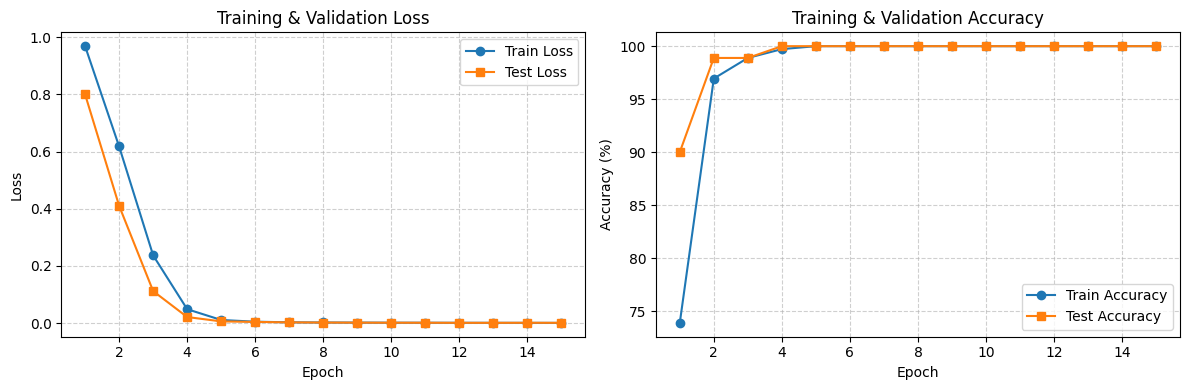

In [8]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), train_losses, label='Train Loss', marker='o')
plt.plot(range(1, epochs + 1), test_losses, label='Test Loss', marker='s')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), np.array(train_accs)*100, label='Train Accuracy', marker='o')
plt.plot(range(1, epochs + 1), np.array(test_accs)*100, label='Test Accuracy', marker='s')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


=== FINAL MODEL EVALUATION REPORT ===
Overall Test Accuracy: 100.00%

              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        30
     Neutral       1.00      1.00      1.00        30
    Positive       1.00      1.00      1.00        30

    accuracy                           1.00        90
   macro avg       1.00      1.00      1.00        90
weighted avg       1.00      1.00      1.00        90



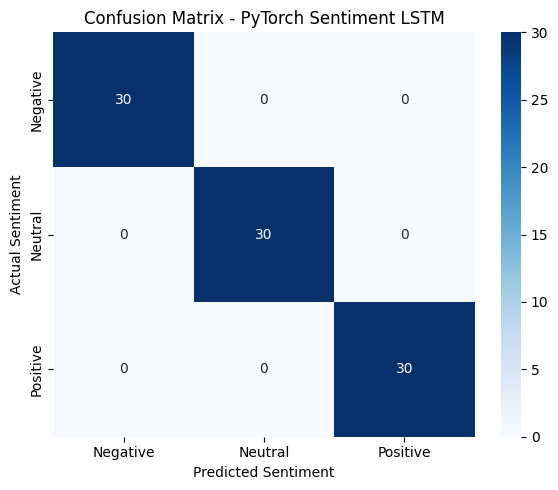

In [9]:
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for seqs, labels in test_loader:
        seqs = seqs.to(device)
        outputs = model(seqs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(labels.numpy())

class_names = ['Negative', 'Neutral', 'Positive']

print("=== FINAL MODEL EVALUATION REPORT ===")
acc = accuracy_score(all_targets, all_preds)
print(f"Overall Test Accuracy: {acc*100:.2f}%\n")

report_dict = classification_report(all_targets, all_preds, target_names=class_names, output_dict=True)
print(classification_report(all_targets, all_preds, target_names=class_names))

cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - PyTorch Sentiment LSTM')
plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')
plt.tight_layout()
plt.show()


In [10]:
def predict_sentiment(text, model, vocab, max_len, device):
    model.eval()
    cleaned = clean_text(text)
    seq = text_to_left_padded_sequence(cleaned, vocab, max_len)
    seq_tensor = torch.tensor([seq], dtype=torch.long).to(device)
    with torch.no_grad():
        logits = model(seq_tensor)
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
        pred_class_idx = np.argmax(probs)
    
    class_map = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
    return class_map[pred_class_idx], probs

test_samples = [
    ("The engine performance is outstanding and accelerates smoothly.", "Positive"),
    ("Infotainment screen is impressive, responsive, and intuitive to use.", "Positive"),
    ("The engine performance is terrible and overheats quickly.", "Negative"),
    ("Cabin noise level is dreadful and intrusive during travel.", "Negative"),
    ("The engine displacement is measured at 2.0 liters.", "Neutral"),
    ("Electrical battery system operates at 40 volts.", "Neutral")
]

print("=== SAMPLE INFERENCE VERIFICATION ===")
for text, true_sentiment in test_samples:
    pred_sentiment, probs = predict_sentiment(text, model, vocab, max_len, device)
    neg_p, neu_p, pos_p = probs[0], probs[1], probs[2]
    print(f"Input Text   : \"{text}\"")
    print(f"Expected     : {true_sentiment}")
    print(f"Predicted    : {pred_sentiment} (P(Neg)={neg_p:.3f}, P(Neu)={neu_p:.3f}, P(Pos)={pos_p:.3f})")
    print("-" * 75)


=== SAMPLE INFERENCE VERIFICATION ===
Input Text   : "The engine performance is outstanding and accelerates smoothly."
Expected     : Positive
Predicted    : Positive (P(Neg)=0.000, P(Neu)=0.000, P(Pos)=0.999)
---------------------------------------------------------------------------
Input Text   : "Infotainment screen is impressive, responsive, and intuitive to use."
Expected     : Positive
Predicted    : Positive (P(Neg)=0.000, P(Neu)=0.000, P(Pos)=0.999)
---------------------------------------------------------------------------
Input Text   : "The engine performance is terrible and overheats quickly."
Expected     : Negative
Predicted    : Negative (P(Neg)=0.998, P(Neu)=0.000, P(Pos)=0.001)
---------------------------------------------------------------------------
Input Text   : "Cabin noise level is dreadful and intrusive during travel."
Expected     : Negative
Predicted    : Negative (P(Neg)=0.999, P(Neu)=0.000, P(Pos)=0.000)
----------------------------------------------------